# CMIP6 Bulk Download and Validation - New York
Download all CMIP6 climate models for New York location and validate downloads with plots and summary report.

## 1. Configuration
Set download parameters for New York HadCRUT5 gridbox.

In [1]:
import subprocess
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

# Configuration
LOCATION = "NewYork"
AREA = [45, -75, 40, -70]  # HadCRUT5 gridbox (40-45°N, 70-75°W) containing NYC: N, W, S, E
DOWNLOAD_DIR = "CMIP6"

print(f"Location: {LOCATION}")
print(f"Area (N, W, S, E): {AREA}")
print(f"Download directory: {DOWNLOAD_DIR}")

Location: NewYork
Area (N, W, S, E): [45, -75, 40, -70]
Download directory: CMIP6


## 2a. Download All Models (Download-Only)
Download tasmax and tasmin for all models without processing.

**Note:** This may take a long time depending on number of models and available bandwidth.

In [2]:
# Download all models (download-only)
cmd = [
    sys.executable,
    "../scripts/download_all_models.py",
    "--location", LOCATION,
    "--area", str(AREA[0]), str(AREA[1]), str(AREA[2]), str(AREA[3]),
    "--download-dir", DOWNLOAD_DIR,
    "--download-only",
]

print(f"Running: {' '.join(cmd)}\n")
result = subprocess.run(cmd, capture_output=False, text=True)

if result.returncode == 0:
    print("\nBulk download complete!")
else:
    print(f"\nScript failed with return code {result.returncode}")

Running: /Users/shaleni/Documents/GitHub/Copernicus/.venv/bin/python ../scripts/download_all_models.py --location NewYork --area 45 -75 40 -70 --download-dir CMIP6 --download-only


CMIP6 BULK DOWNLOAD AND PROCESSING
Start time: 2026-02-25 20:16:58
Location: NewYork
Area: [45.0, -75.0, 40.0, -70.0]
Mode: DOWNLOAD ONLY


BULK DOWNLOAD: NewYork
Area (N, W, S, E): [45.0, -75.0, 40.0, -70.0]
Models to download: 19
Variables: tasmax, tasmin
Experiments: historical, ssp126, ssp245, ssp585


[1/19] Downloading ACCESS-CM2...
✓ File already exists, skipping: cmip6_tasmax_ACCESS-CM2_historical_1850-2014.nc
✓ File already exists, skipping: cmip6_tasmax_ACCESS-CM2_ssp126_2015-2300.nc
✓ File already exists, skipping: cmip6_tasmax_ACCESS-CM2_ssp245_2015-2300.nc
✓ File already exists, skipping: cmip6_tasmax_ACCESS-CM2_ssp585_2015-2300.nc
✓ File already exists, skipping: cmip6_tasmin_ACCESS-CM2_historical_1850-2014.nc
✓ File already exists, skipping: cmip6_tasmin_ACCESS-CM2_ssp126_2015-2300.nc
✓ File 

2026-02-25 20:16:59,214 INFO [2026-02-25T00:00:00Z] Please note that the announced software upgrade for extracting geographical-area data from selected ERA5 and Seasonal Forecast datasets was successfully implemented on 25 February. For further details, please [visit our forum announcement](https://forum.ecmwf.int/t/software-upgrade-for-data-extraction-of-a-geographical-area-from-selected-era5-and-seasonal-forecast-datasets/14583).


## 2b. Process Existing Downloads
Process already-downloaded files to create anomalies, summary report, and plots.

In [3]:
# Process existing downloads (no download)
cmd = [
    sys.executable,
    "../scripts/download_all_models.py",
    "--location", LOCATION,
    "--area", str(AREA[0]), str(AREA[1]), str(AREA[2]), str(AREA[3]),
    "--download-dir", DOWNLOAD_DIR,
    "--process-only",
]

print(f"Running: {' '.join(cmd)}\n")
result = subprocess.run(cmd, capture_output=False, text=True)

if result.returncode == 0:
    print("\nProcessing complete!")
else:
    print(f"\nScript failed with return code {result.returncode}")

Running: /Users/shaleni/Documents/GitHub/Copernicus/.venv/bin/python ../scripts/download_all_models.py --location NewYork --area 45 -75 40 -70 --download-dir CMIP6 --process-only


CMIP6 BULK DOWNLOAD AND PROCESSING
Start time: 2026-02-25 20:17:00
Location: NewYork
Area: [45.0, -75.0, 40.0, -70.0]
Mode: PROCESS ONLY


PROCESSING AND COMPUTING ANOMALIES

[1/19] Processing ACCESS-CM2...
  - Combining tasmax with scenarios... Loaded historical: 1980 timesteps
Loaded ssp126: 1032 timesteps
✓ Saved cmip6_tasmax_ACCESS-CM2_historical+ssp126_1850-2300.nc
  Total timesteps: 3012
Loaded ssp245: 1032 timesteps
✓ Saved cmip6_tasmax_ACCESS-CM2_historical+ssp245_1850-2300.nc
  Total timesteps: 3012
Loaded ssp585: 1032 timesteps
✓ Saved cmip6_tasmax_ACCESS-CM2_historical+ssp585_1850-2300.nc
  Total timesteps: 3012
✓
  - Combining tasmin with scenarios... Loaded historical: 1980 timesteps
Loaded ssp126: 1032 timesteps
✓ Saved cmip6_tasmin_ACCESS-CM2_historical+ssp126_1850-2300.nc
  Total timesteps: 3

## 3. View Summary Report
Load and display the summary CSV with date ranges for all models.

In [4]:
summary_file = Path(DOWNLOAD_DIR) / f"{LOCATION}_summary.csv"

if summary_file.exists():
    df_summary = pd.read_csv(summary_file)
    print(f"\nSummary Report: {summary_file}\n")
    display(df_summary)
    
    # Statistics
    successful = len(df_summary[df_summary["Status"] == "success"])
    total = len(df_summary)
    print(f"\nSuccessful: {successful}/{total} models")
    
else:
    print(f"Summary file not found: {summary_file}")


Summary Report: CMIP6/NewYork_summary.csv



,Model,Status,Time Min,Time Max,Timesteps
0,ACCESS-CM2,success,1850,2100,3012
1,CanESM5-CanOE,success,1850,2100,3012
2,CIESM,success,1850,2100,3012
3,CMCC-ESM2,success,1850,2100,3012
4,CNRM-CM6-1,success,1850,2100,3012
5,CNRM-CM6-1-HR,success,1850,2100,3012
6,CNRM-ESM2-1,success,1850,2100,3012
7,FIO-ESM-2-0,success,1850,2100,3012
8,GFDL-ESM4,success,1850,2100,3012
9,HadGEM3-GC31-LL,success,1850,2100,3012



Successful: 19/19 models


## 4. Generate Plots
Generate plots from existing summary and outputs.

In [5]:
# Generate plots from existing outputs (plot-only)
cmd = [
    sys.executable,
    "../scripts/download_all_models.py",
    "--location", LOCATION,
    "--area", str(AREA[0]), str(AREA[1]), str(AREA[2]), str(AREA[3]),
    "--download-dir", DOWNLOAD_DIR,
    "--plot-only",
]

print(f"Running: {' '.join(cmd)}\n")
result = subprocess.run(cmd, capture_output=False, text=True)

if result.returncode == 0:
    print("\nPlot generation complete!")
else:
    print(f"\nScript failed with return code {result.returncode}")

Running: /Users/shaleni/Documents/GitHub/Copernicus/.venv/bin/python ../scripts/download_all_models.py --location NewYork --area 45 -75 40 -70 --download-dir CMIP6 --plot-only


CMIP6 BULK DOWNLOAD AND PROCESSING
Start time: 2026-02-25 20:18:03
Location: NewYork
Area: [45.0, -75.0, 40.0, -70.0]
Mode: DOWNLOAD AND PROCESS

Creating avg plots for 19 models (7x3 grid)...
✓ Plot saved to: CMIP6/NewYork_plots_avg.png

Plot-only complete.

Plot generation complete!


## 4b. Display Temperature Anomaly Plots
Grid of temperature anomalies (1961-1990 baseline) for all models. Each plot shows historical period (black) and SSP scenarios (green/orange/red).

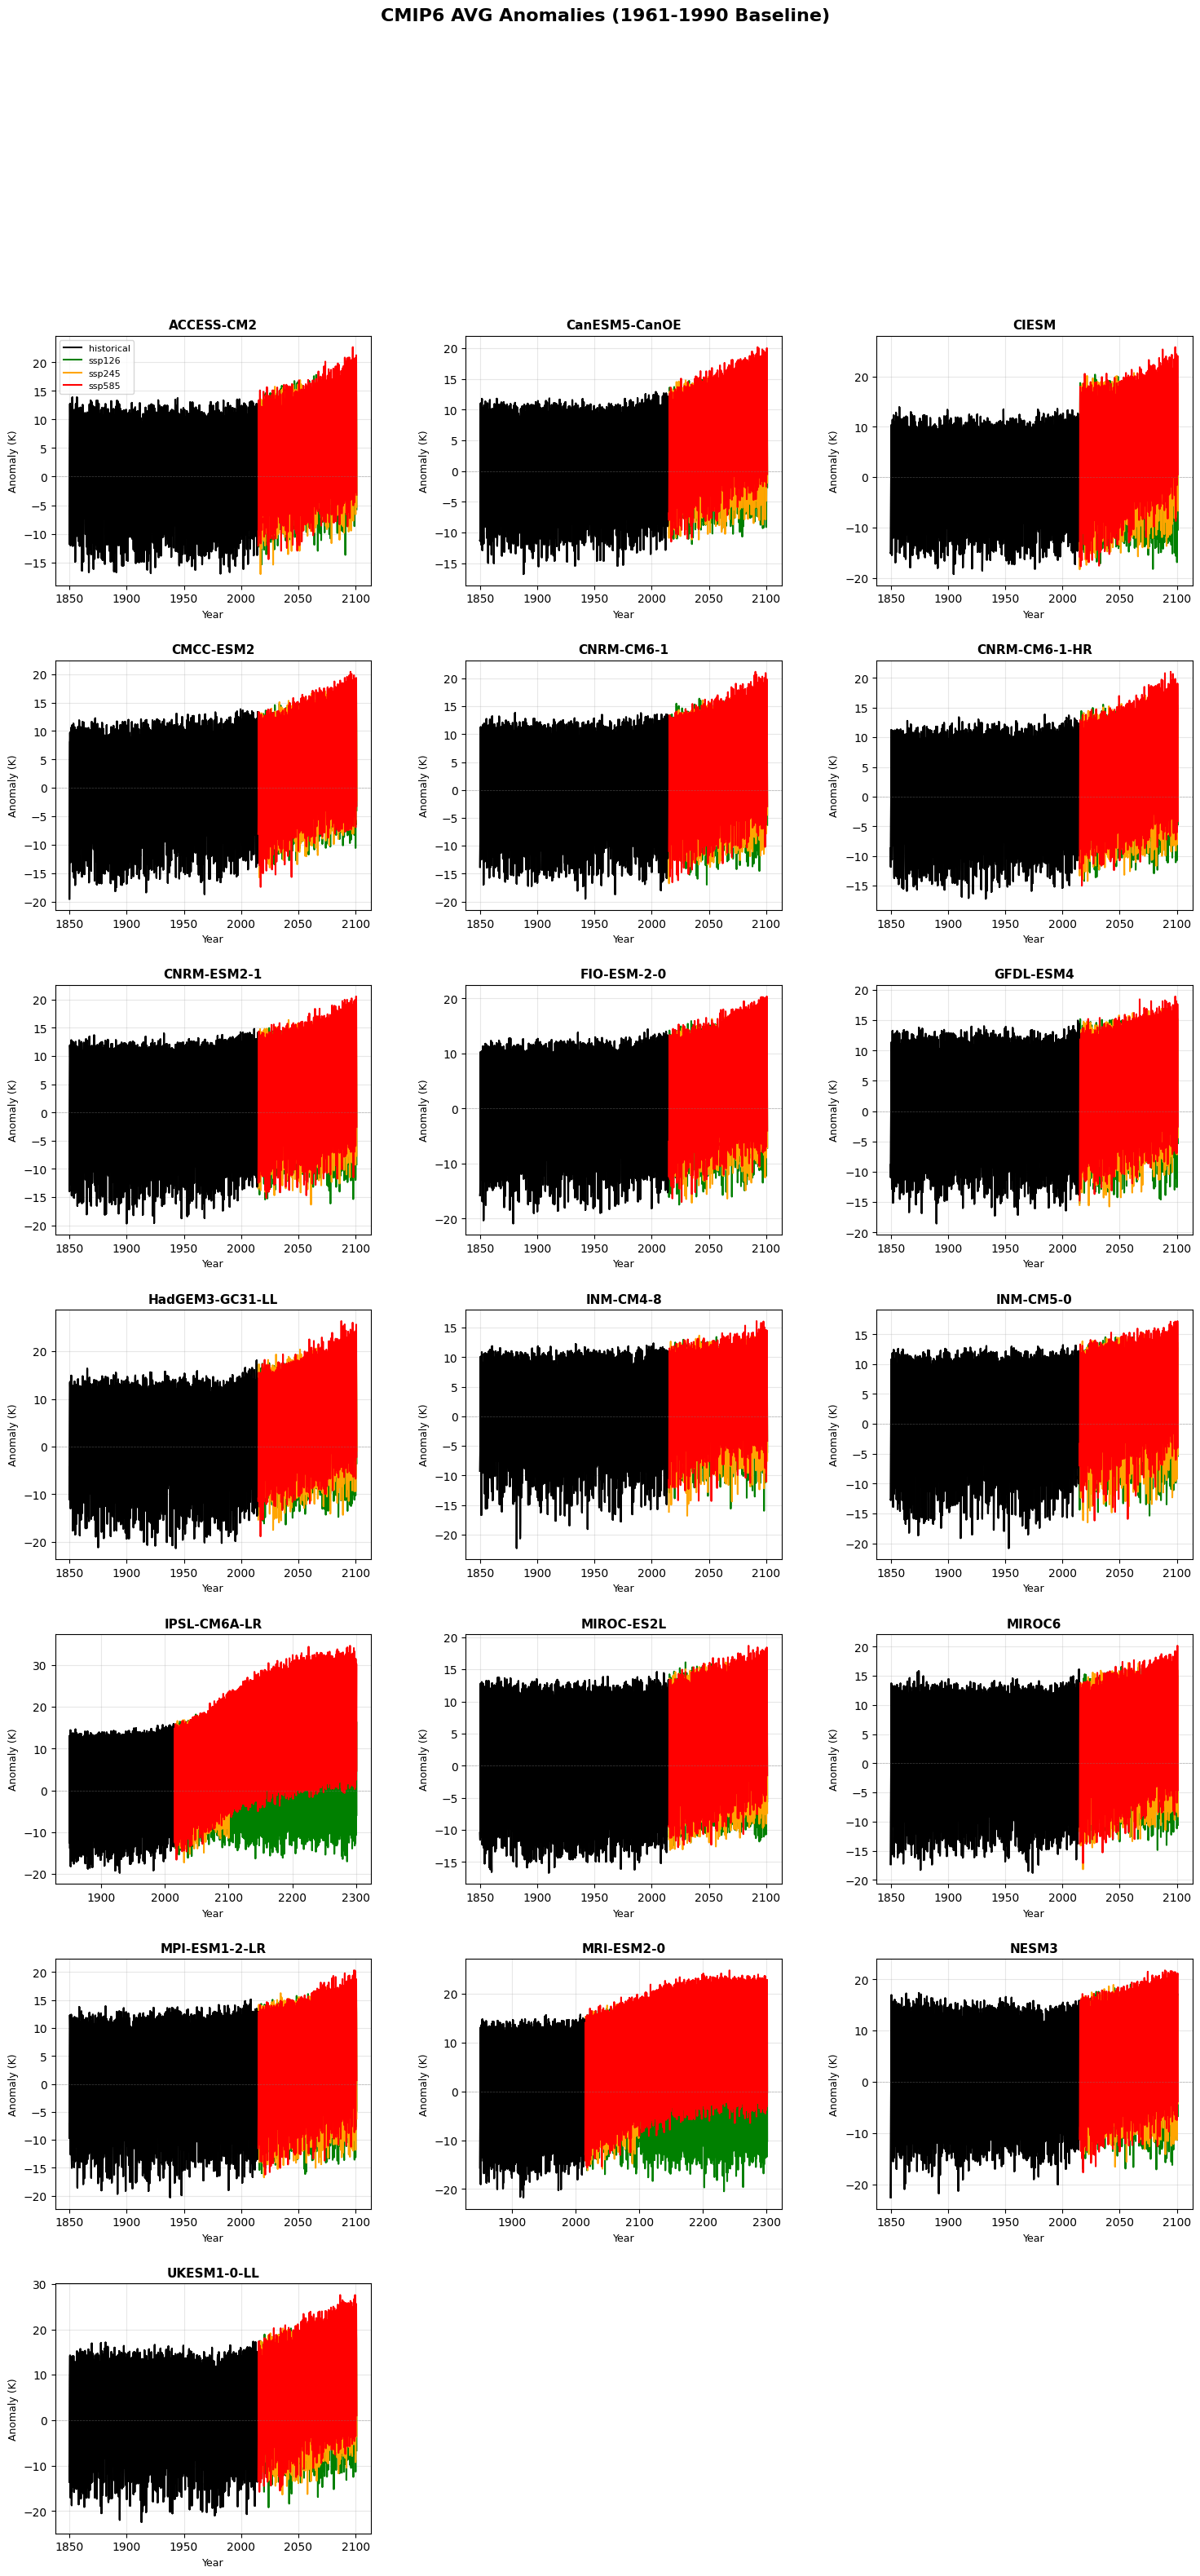

✓ Temperature anomaly plots: CMIP6/NewYork_plots_avg.png


In [6]:
plot_file = Path(DOWNLOAD_DIR) / f"{LOCATION}_plots_avg.png"

if plot_file.exists():
    display(Image(str(plot_file)))
    print(f"✓ Temperature anomaly plots: {plot_file}")
else:
    print(f"Plot file not found: {plot_file}")

## 5. Combine All Models into Location Files
Create location-wide anomaly files (monthly and JJA) that include all models.

In [7]:
# Combine all models into location-wide files (monthly + JJA)
cmd = [
    sys.executable,
    "../scripts/download_all_models.py",
    "--location", LOCATION,
    "--area", str(AREA[0]), str(AREA[1]), str(AREA[2]), str(AREA[3]),
    "--download-dir", DOWNLOAD_DIR,
    "--combine-only",
    "--max-year", "2100",
]

print(f"Running: {' '.join(cmd)}\n")
result = subprocess.run(cmd, capture_output=False, text=True)

if result.returncode == 0:
    print("\nLocation-wide combine complete!")
else:
    print(f"\nScript failed with return code {result.returncode}")

Running: /Users/shaleni/Documents/GitHub/Copernicus/.venv/bin/python ../scripts/download_all_models.py --location NewYork --area 45 -75 40 -70 --download-dir CMIP6 --combine-only --max-year 2100


CMIP6 BULK DOWNLOAD AND PROCESSING
Start time: 2026-02-25 20:18:08
Location: NewYork
Area: [45.0, -75.0, 40.0, -70.0]
Mode: DOWNLOAD AND PROCESS

✓ Combined monthly file saved: CMIP6/NewYork/NewYork_temperature_anomalies_all_models_1961-1990baseline.nc
✓ Combined jja file saved: CMIP6/NewYork/NewYork_temperature_anomalies_JJA_all_models_1961-1990baseline.nc
Combine-only complete.

Location-wide combine complete!
